In [1]:
## Imports
import torch
import torchvision ## Contains some utilities for working with the image data
from torchvision.datasets import MNIST
import matplotlib.pyplot as plt
#%matplotlib inline
import torchvision.transforms as transforms
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [2]:
dataset = MNIST(root = 'data/', download = True)
print(len(dataset))

60000


Label: 3


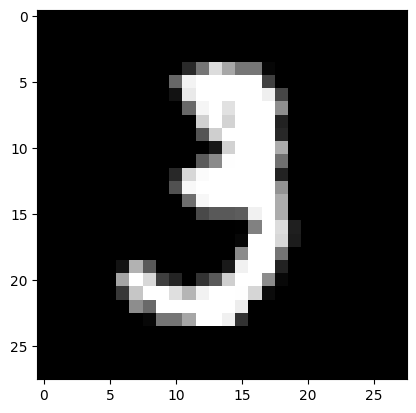

In [3]:
image, label = dataset[10]
plt.imshow(image, cmap = 'gray')
print('Label:', label)

In [4]:
## MNIST dataset(images and labels)
mnist_dataset = MNIST(root = 'data/', train = True, transform = transforms.ToTensor())
print(mnist_dataset)

Dataset MNIST
    Number of datapoints: 60000
    Root location: data/
    Split: Train
    StandardTransform
Transform: ToTensor()


In [5]:
image_tensor, label = mnist_dataset[0]
print(image_tensor.shape, label)

torch.Size([1, 28, 28]) 5


In [6]:
print(image_tensor[:,10:15,10:15])
print(torch.max(image_tensor), torch.min(image_tensor))

tensor([[[0.0039, 0.6039, 0.9922, 0.3529, 0.0000],
         [0.0000, 0.5451, 0.9922, 0.7451, 0.0078],
         [0.0000, 0.0431, 0.7451, 0.9922, 0.2745],
         [0.0000, 0.0000, 0.1373, 0.9451, 0.8824],
         [0.0000, 0.0000, 0.0000, 0.3176, 0.9412]]])
tensor(1.) tensor(0.)


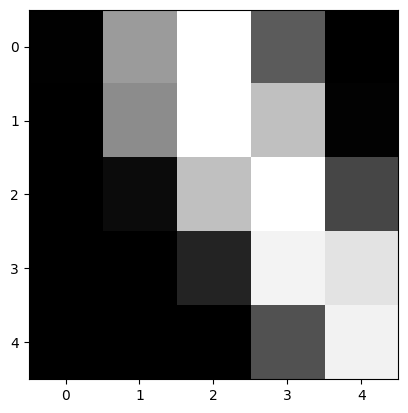

In [7]:
## Plot the image of the tensor
plt.imshow(image_tensor[0,10:15,10:15],cmap = 'gray')

In [8]:
train_data, validation_data = random_split(mnist_dataset, [50000, 10000])
## Print the length of train and validation datasets
print("length of Train Datasets: ", len(train_data))
print("length of Validation Datasets: ", len(validation_data))

length of Train Datasets:  50000
length of Validation Datasets:  10000


In [9]:
batch_size = 128
train_loader = DataLoader(train_data, batch_size, shuffle = True)
val_loader = DataLoader(validation_data, batch_size, shuffle = False)

In [10]:
import torch.nn as nn

input_size = 28 * 28
num_classes = 10

## Logistic regression model
model = nn.Linear(input_size, num_classes)
print(model.weight.shape)
print(model.weight)
print(model.bias.shape)
print(model.bias)

torch.Size([10, 784])
Parameter containing:
tensor([[-0.0234,  0.0054,  0.0239,  ...,  0.0182, -0.0285,  0.0089],
        [-0.0211,  0.0004, -0.0057,  ...,  0.0002, -0.0210, -0.0008],
        [-0.0113,  0.0258, -0.0056,  ...,  0.0286, -0.0058,  0.0042],
        ...,
        [-0.0034, -0.0188, -0.0277,  ..., -0.0203, -0.0116,  0.0148],
        [-0.0182, -0.0354,  0.0329,  ..., -0.0015,  0.0133, -0.0108],
        [-0.0026, -0.0147,  0.0208,  ...,  0.0092, -0.0194, -0.0325]],
       requires_grad=True)
torch.Size([10])
Parameter containing:
tensor([-0.0339,  0.0039,  0.0074, -0.0053, -0.0054,  0.0085,  0.0137,  0.0200,
         0.0310, -0.0315], requires_grad=True)


In [11]:
for images, labels in train_loader:
    print(labels)
    print(images.shape)
    outputs = model(images)
    break

tensor([6, 8, 0, 2, 6, 4, 0, 4, 3, 2, 7, 8, 7, 1, 3, 6, 4, 5, 3, 2, 8, 3, 5, 5,
        6, 2, 9, 4, 1, 9, 0, 9, 1, 6, 7, 8, 1, 5, 7, 6, 7, 9, 7, 6, 6, 5, 2, 1,
        3, 8, 0, 0, 8, 3, 8, 5, 8, 7, 5, 5, 4, 2, 8, 6, 4, 9, 7, 5, 9, 5, 8, 3,
        1, 8, 3, 8, 2, 5, 0, 1, 8, 0, 7, 7, 9, 9, 5, 2, 5, 3, 4, 5, 8, 7, 1, 4,
        0, 9, 4, 0, 2, 7, 6, 9, 7, 7, 0, 0, 5, 4, 8, 5, 1, 0, 2, 6, 5, 8, 6, 4,
        4, 3, 1, 8, 4, 8, 3, 6])
torch.Size([128, 1, 28, 28])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)

In [ ]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        print(xb)
        out = self.linear(xb)
        print(out)
        return(out)

model = MnistModel()
print(model.linear.weight.shape, model.linear.bias.shape)
list(model.parameters())

torch.Size([10, 784]) torch.Size([10])


[Parameter containing:
 tensor([[ 0.0005,  0.0223, -0.0241,  ..., -0.0034,  0.0020, -0.0159],
         [-0.0068,  0.0285, -0.0026,  ...,  0.0173, -0.0229, -0.0210],
         [ 0.0345, -0.0249,  0.0263,  ...,  0.0269,  0.0099, -0.0081],
         ...,
         [ 0.0193, -0.0056,  0.0029,  ..., -0.0037, -0.0109,  0.0144],
         [-0.0017,  0.0105, -0.0044,  ..., -0.0319, -0.0262, -0.0147],
         [-0.0298,  0.0025, -0.0147,  ..., -0.0135,  0.0172, -0.0020]],
        requires_grad=True),
 Parameter containing:
 tensor([ 0.0267,  0.0047,  0.0053,  0.0160, -0.0132, -0.0058, -0.0240,  0.0092,
          0.0281, -0.0285], requires_grad=True)]

In [ ]:
for images, labels in train_loader:
    outputs = model(images)
    break
    
print('outputs shape: ', outputs.shape)
print('Sample outputs: \n', outputs[:2].data)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])
tensor([[-0.2097, -0.2545,  0.0345,  ...,  0.0879,  0.2879, -0.2263],
        [-0.2246, -0.0018,  0.1774,  ..., -0.1529,  0.0581, -0.2215],
        [-0.2063, -0.0242, -0.0396,  ..., -0.2738,  0.0357,  0.0367],
        ...,
        [ 0.0570,  0.0817,  0.1187,  ...,  0.0646,  0.1949, -0.1239],
        [ 0.1271, -0.0340, -0.0347,  ..., -0.0276,  0.0367,  0.0788],
        [ 0.0375,  0.0259, -0.0931,  ...,  0.1456, -0.0389, -0.0945]],
       grad_fn=<AddmmBackward0>)
outputs shape:  torch.Size([128, 10])
Sample outputs: 
 tensor([[-0.2097, -0.2545,  0.0345,  0.0781,  0.1468, -0.1511, -0.1027,  0.0879,
          0.2879, -0.2263],
        [-0.2246, -0.0018,  0.1774, -0.0095,  0.0506, -0.2574,  0.0358, -0.1529,
          0.0581, -0.2215]])


In [ ]:
## Apply softmax for each output row
probs = F.softmax(outputs, dim = 1)

## chaecking at sample probabilities
print("Sample probabilities:\n", probs[:2].data)

print("\n")
## Add up the probabilities of an output row
print("Sum: ", torch.sum(probs[0]).item())
max_probs, preds = torch.max(probs, dim = 1)
print("\n")
print(preds)
print("\n")
print(max_probs)

Sample probabilities:
 tensor([[0.0824, 0.0787, 0.1051, 0.1098, 0.1176, 0.0873, 0.0917, 0.1109, 0.1355,
         0.0810],
        [0.0835, 0.1044, 0.1249, 0.1036, 0.1100, 0.0808, 0.1084, 0.0898, 0.1108,
         0.0838]])


Sum:  1.0


tensor([8, 2, 3, 7, 8, 2, 8, 1, 7, 4, 2, 2, 2, 1, 4, 3, 2, 2, 8, 8, 2, 1, 8, 2,
        8, 8, 9, 4, 2, 4, 2, 2, 2, 8, 8, 8, 2, 8, 2, 4, 3, 2, 7, 8, 8, 2, 8, 6,
        8, 4, 3, 2, 7, 8, 0, 8, 8, 4, 8, 3, 1, 0, 8, 3, 2, 8, 8, 4, 8, 7, 7, 2,
        2, 8, 4, 3, 1, 4, 4, 1, 8, 2, 8, 3, 2, 3, 3, 2, 2, 7, 2, 8, 0, 4, 4, 8,
        8, 2, 8, 8, 3, 3, 9, 7, 4, 2, 3, 8, 2, 0, 8, 8, 7, 8, 7, 3, 9, 7, 3, 1,
        8, 4, 6, 7, 4, 8, 0, 7])


tensor([0.1355, 0.1249, 0.1143, 0.1293, 0.1439, 0.1322, 0.1299, 0.1344, 0.1173,
        0.1178, 0.1194, 0.1399, 0.1493, 0.1139, 0.1203, 0.1209, 0.1291, 0.1746,
        0.1288, 0.1464, 0.1228, 0.1206, 0.1211, 0.1318, 0.1254, 0.1298, 0.1210,
        0.1378, 0.1335, 0.1368, 0.1182, 0.1249, 0.1259, 0.1256, 0.1417, 0.1385,
        0

In [ ]:
labels

tensor([8, 4, 3, 1, 7, 8, 0, 6, 5, 9, 8, 9, 2, 1, 4, 3, 8, 5, 0, 6, 4, 1, 6, 9,
        3, 6, 6, 6, 0, 6, 6, 8, 8, 7, 6, 4, 8, 2, 5, 3, 3, 8, 1, 6, 4, 4, 7, 9,
        9, 1, 0, 6, 1, 2, 2, 8, 6, 3, 0, 0, 7, 6, 0, 7, 1, 0, 2, 2, 4, 1, 1, 7,
        9, 9, 9, 8, 3, 5, 4, 3, 9, 5, 7, 3, 3, 8, 3, 4, 3, 4, 3, 0, 8, 5, 9, 7,
        5, 7, 0, 5, 0, 7, 6, 2, 7, 8, 3, 8, 5, 1, 4, 6, 1, 7, 1, 0, 4, 8, 5, 6,
        4, 0, 6, 1, 6, 3, 2, 1])

In [ ]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim = 1)
    return(torch.tensor(torch.sum(preds == labels).item()/ len(preds)))

print("Accuracy: ",accuracy(outputs, labels))
print("\n")
loss_fn = F.cross_entropy
print("Loss Function: ",loss_fn)
print("\n")
## Loss for the current batch
loss = loss_fn(outputs, labels)
print(loss)

Accuracy:  tensor(0.1172)


Loss Function:  <function cross_entropy at 0x0000028ACB1EEDE0>


tensor(2.2904, grad_fn=<NllLossBackward0>)


In [ ]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_classes)
    
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return(out)
    
    def training_step(self, batch):
        images, labels = batch
        out = self(images) ## Generate predictions
        loss = F.cross_entropy(out, labels) ## Calculate the loss
        return(loss)
    
    def validation_step(self, batch):
        images, labels = batch
        out = self(images)
        loss = F.cross_entropy(out, labels)
        acc = accuracy(out, labels)
        return({'val_loss':loss, 'val_acc': acc})
    
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()
        return({'val_loss': epoch_loss.item(), 'val_acc' : epoch_acc.item()})
    
    def epoch_end(self, epoch,result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))
        
    
model = MnistModel()

In [ ]:
def evaluate(model, val_loader):
    outputs = [model.validation_step(batch) for batch in val_loader]
    return(model.validation_epoch_end(outputs))

def fit(epochs, lr, model, train_loader, val_loader, opt_func = torch.optim.SGD):
    history = []
    optimizer = opt_func(model.parameters(), lr)
    for epoch in range(epochs):
        
        ## Training Phas
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        ## Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)
    return(history)

In [ ]:
result0 = evaluate(model, val_loader)
result0

{'val_loss': 2.251652956008911, 'val_acc': 0.1514042764902115}

In [ ]:
history1 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.8990, val_acc: 0.6392
Epoch [1], val_loss: 1.6400, val_acc: 0.7271
Epoch [2], val_loss: 1.4473, val_acc: 0.7677
Epoch [3], val_loss: 1.3021, val_acc: 0.7867
Epoch [4], val_loss: 1.1904, val_acc: 0.7971


In [ ]:
history2 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 1.1025, val_acc: 0.8074
Epoch [1], val_loss: 1.0319, val_acc: 0.8133
Epoch [2], val_loss: 0.9740, val_acc: 0.8202
Epoch [3], val_loss: 0.9257, val_acc: 0.8245
Epoch [4], val_loss: 0.8848, val_acc: 0.8281


In [ ]:
history3 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.8498, val_acc: 0.8329
Epoch [1], val_loss: 0.8194, val_acc: 0.8360
Epoch [2], val_loss: 0.7927, val_acc: 0.8381
Epoch [3], val_loss: 0.7692, val_acc: 0.8400
Epoch [4], val_loss: 0.7482, val_acc: 0.8426


In [ ]:
history4 = fit(5, 0.001, model, train_loader, val_loader)

Epoch [0], val_loss: 0.7293, val_acc: 0.8447
Epoch [1], val_loss: 0.7123, val_acc: 0.8455
Epoch [2], val_loss: 0.6969, val_acc: 0.8478
Epoch [3], val_loss: 0.6828, val_acc: 0.8499
Epoch [4], val_loss: 0.6698, val_acc: 0.8518


Text(0.5, 1.0, 'Accuracy Vs. No. of epochs')

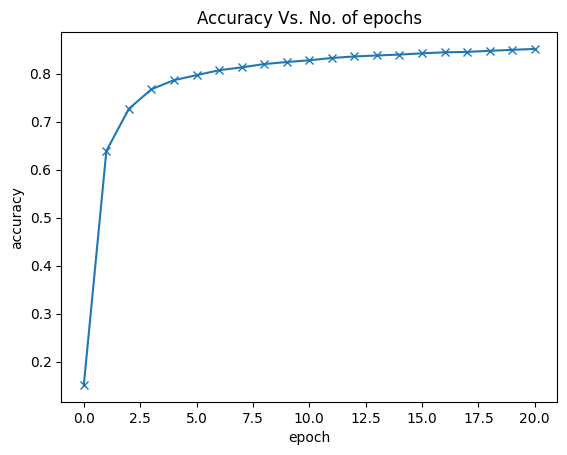

In [ ]:
## Replace these values with your result
history = [result0] + history1 + history2 + history3 + history4
accuracies = [result['val_acc'] for result in history]
plt.plot(accuracies, '-x')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.title('Accuracy Vs. No. of epochs')

In [ ]:
## Define the test dataset
test_dataset = MNIST(root = 'data/', train = False, transform = transforms.ToTensor())

shape:  torch.Size([1, 28, 28])
Label:  7


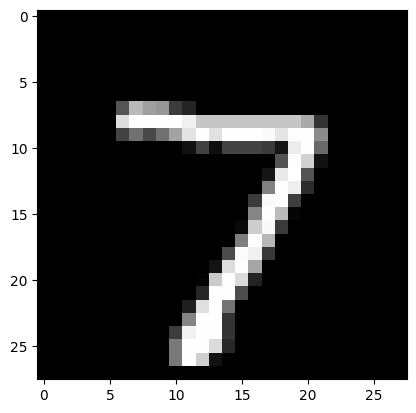

In [ ]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print("shape: ", img.shape)
print('Label: ', label)

In [ ]:
print(img.unsqueeze(0).shape)
print(img.shape)

torch.Size([1, 1, 28, 28])
torch.Size([1, 28, 28])


In [ ]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb, dim = 1)
    return(preds[0].item())

Label: 7 , Predicted : 7


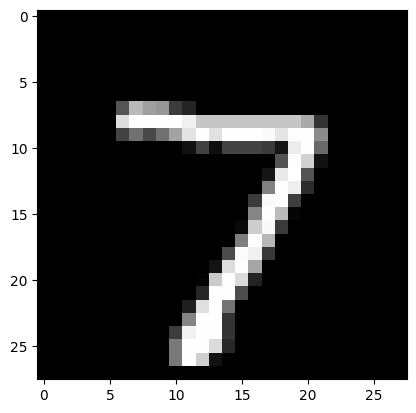

In [ ]:
img, label = test_dataset[0]
plt.imshow(img[0], cmap = 'gray')
print('Label:', label, ', Predicted :', predict_image(img, model))

Label: 9 ,Predicted: 9


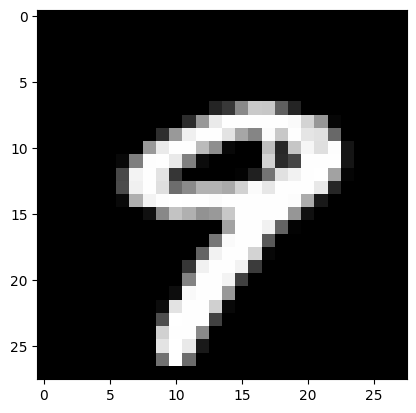

In [ ]:
img, label = test_dataset[9]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

Label: 0 ,Predicted: 0


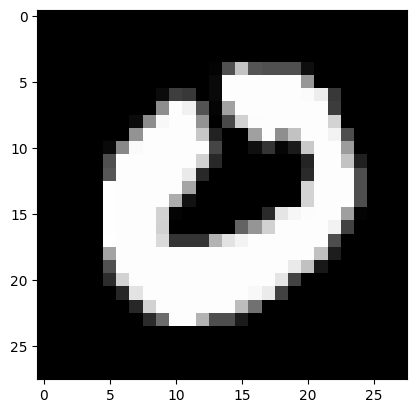

In [ ]:
img, label = test_dataset[25]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

Label: 3 ,Predicted: 3


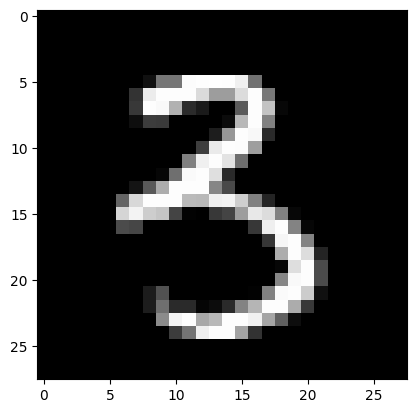

In [ ]:
img, label = test_dataset[5000]
plt.imshow(img[0], cmap = 'gray')
print("Label:", label, ',Predicted:', predict_image(img, model))

In [ ]:
test_loader = DataLoader(test_dataset, batch_size = 256)
result = evaluate(model, test_loader)
result

{'val_loss': 0.638649582862854, 'val_acc': 0.860058605670929}

In [ ]:
torch.save(model.state_dict(), 'mnist-logistic.pth')

In [ ]:
model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0263, -0.0153, -0.0036,  ..., -0.0145, -0.0133,  0.0137],
                      [ 0.0280,  0.0025,  0.0082,  ..., -0.0266,  0.0191,  0.0103],
                      [ 0.0018, -0.0290, -0.0081,  ...,  0.0195, -0.0149, -0.0100],
                      ...,
                      [ 0.0019, -0.0106, -0.0188,  ...,  0.0325,  0.0015, -0.0327],
                      [-0.0188,  0.0277,  0.0240,  ...,  0.0216, -0.0238,  0.0100],
                      [ 0.0118, -0.0070, -0.0085,  ...,  0.0171,  0.0218, -0.0298]])),
             ('linear.bias',
              tensor([-0.0395,  0.0938, -0.0470, -0.0525, -0.0035,  0.0553, -0.0419,  0.0632,
                      -0.0759,  0.0059]))])

In [ ]:
model2 = MnistModel()
model2.load_state_dict(torch.load('mnist-logistic.pth'))
model2.state_dict()    

OrderedDict([('linear.weight',
              tensor([[ 0.0263, -0.0153, -0.0036,  ..., -0.0145, -0.0133,  0.0137],
                      [ 0.0280,  0.0025,  0.0082,  ..., -0.0266,  0.0191,  0.0103],
                      [ 0.0018, -0.0290, -0.0081,  ...,  0.0195, -0.0149, -0.0100],
                      ...,
                      [ 0.0019, -0.0106, -0.0188,  ...,  0.0325,  0.0015, -0.0327],
                      [-0.0188,  0.0277,  0.0240,  ...,  0.0216, -0.0238,  0.0100],
                      [ 0.0118, -0.0070, -0.0085,  ...,  0.0171,  0.0218, -0.0298]])),
             ('linear.bias',
              tensor([-0.0395,  0.0938, -0.0470, -0.0525, -0.0035,  0.0553, -0.0419,  0.0632,
                      -0.0759,  0.0059]))])

In [ ]:
test_loader = DataLoader(test_dataset, batch_size = 256)
result = evaluate(model2, test_loader)
result

{'val_loss': 0.638649582862854, 'val_acc': 0.860058605670929}

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
class LogisticRegressionModel(nn.Module):
    def __init__(self):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(28 * 28, 10)  # MNIST input (28x28 flattened) → 10 output classes

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten input
        return self.linear(x)

# Check if CUDA is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize the model
model = LogisticRegressionModel()

# Load the saved state_dict (weights)
model.load_state_dict(torch.load("mnist-logistic.pth", map_location=device))

# Move model to the correct device
model.to(device)

# Load MNIST test dataset
test_dataset = datasets.MNIST(root="./data", train=False, transform=transforms.ToTensor(), download=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculations
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    accuracy = correct / total
    print(f"Model Accuracy: {accuracy * 100:.2f}%")
    return accuracy

# Evaluate model
evaluate_model(model, test_loader, device)

Model Accuracy: 86.27%


0.8627